In [2]:
import numpy as np
from matplotlib import pyplot as plt
import healpy as hp
import sys
sys.path.append('../')
from scripts.true_cmb import true_cmb
from scripts.gen_sims import gen_sims
from scripts.compute_decoupled_cl import compute_decoupled_cl
from scripts.cosine_smoothed_mask import cosine_smoothed_mask

In [3]:
nsims=100
nside=128
npix= hp.nside2npix(nside)
lmax=3*nside -1   
ells = np.arange(lmax + 1)
norm = (ells * (ells+ 1)) / (2 * np.pi)
cmb=np.load('cls_sims_cmb.npy')#pysm sim maps
hilc=np.load('cls_sims_maps.npy')#pysm sim fgds+cmb
hilc2 =np.load('/home/iloveorcas/Internship_Rome/results/cls_sims_hilc2.npy')#self gen hilc with fgds
cmb_th= true_cmb()


/home/iloveorcas/Internship_Rome/results/../scripts/true_cmb.py:11: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=382`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  cl_th = np.loadtxt("https://portal.nersc.gov/project/cmb/pysm-data/pysm_2/camb_lenspotentialCls.dat",skiprows=0, max_rows=382 ,usecols=(1))


In [4]:
def calculate_stats(cls: np.ndarray, cls_th: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Calculate the mean, error, and bias of the input power spectra.
    
    Args:
        cls (np.ndarray): Input power spectra with shape (nsims, lmax, ...) or (nsims, lmax).
        cls_th (np.ndarray): Theoretical power spectra to be compared with.

    Returns:
        tuple[np.ndarray, np.ndarray, np.ndarray]:
            - mean (np.ndarray): The mean of the input power spectra.
            - error (np.ndarray): The error of the input power spectra.
            - bias (np.ndarray): The bias of the input power spectra.
    """
    mean = np.mean(cls, axis=0)
    std = np.std(cls, axis=0)
    
    # Ensure mean and std are at least 2D for consistent indexing

    if mean.ndim == 1:
        error = (std / np.sqrt(nsims))
        bias = (mean-cmb_th ) / cls_th  #not multiplying with norm(fsky)
    else:
        error = (std[2:, 0, 0] / np.sqrt(nsims))
        bias = ( mean[2:, 0, 0] -cls_th ) / cls_th
    
    return mean, error, bias


In [5]:
cmb_maps=gen_sims(nsims)

generating cmb maps

In [6]:
cl_test= []
for i in range(nsims):
    np.random.seed(i)
    cl_test.append(hp.alm2cl((hp.synalm(cmb_th))))
cl_test = np.array(cl_test)
print(cl_test.shape)

(100, 382)


In [7]:
hilc3=np.load('/home/iloveorcas/Internship_Rome/results/nofgds.npy')

In [8]:
# hilc_mean, hilc_error, hilc_bias= calculate_stats(hilc, cmb_th)
raw_mean, raw_error, raw_bias= calculate_stats(cl_test, cmb_th)
hilc3_mean, hilc3_error, hilc3_bias= calculate_stats(hilc3, raw_mean)
hilc2_mean, hilc2_error, hilc2_bias= calculate_stats(hilc2, raw_mean)


In [9]:
mask= cosine_smoothed_mask(nside)
mask= (mask*(-1))+1

In [10]:
raw_map=hp.synfast(raw_mean, nside)#ISSUE
raw_map=np.tile(raw_map, (1, 7))
raw_map = raw_map.reshape(7, npix)

raw_dec= compute_decoupled_cl(raw_map, mask, False, nside, lmax, 7)

bias = (raw_dec[2:,0,0]-raw_mean ) / raw_mean

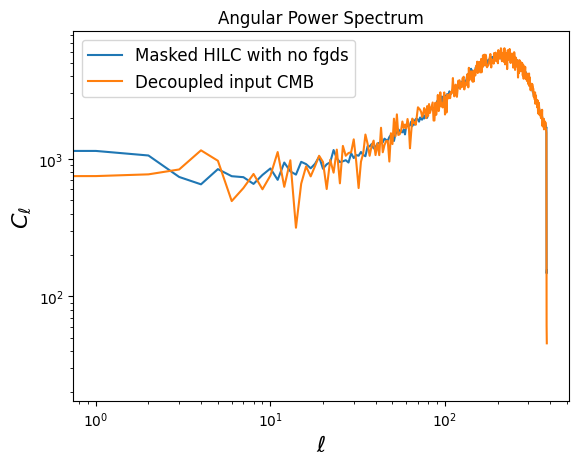

In [11]:
plt.plot(ells, hilc3_mean[:,0,0], label='Masked HILC with no fgds')
plt.plot(ells, raw_dec[:,0,0], label='Decoupled input CMB')
# plt.plot(ells[2:], raw_mean, label='Input CMB')
# plt.plot(ells[2:], dec_smooth_cmb[2:], label='theoretical decoupled CMB')
plt.xlabel('$\\ell$', fontsize=16)
plt.ylabel('$C_\\ell$', fontsize=16)
plt.xscale("log")
plt.yscale("log")
# plt.ylim(1e-3,1e4)
plt.legend(fontsize=12)
plt.title("Angular Power Spectrum")
plt.show()

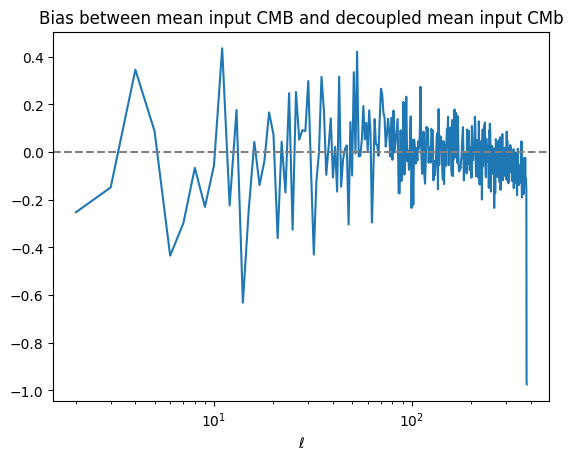

In [12]:
plt.plot(ells[2:], bias, label="raw decoupled") 
plt.axhline(0, linestyle="--", color="gray") 
#plt.ylim(-0.06, 0.06)

plt.xscale("log")
plt.title("Bias between mean input CMB and decoupled mean input CMb")
plt.xlabel(r"$\ell$")
plt.show()


$$Expected Bias_{Saha}= \frac{\langle C_l^{sim}\rangle - \langle C_l^{theory}\rangle}{C_l^{theory}} = -\frac{n_f}{2l+1}$$

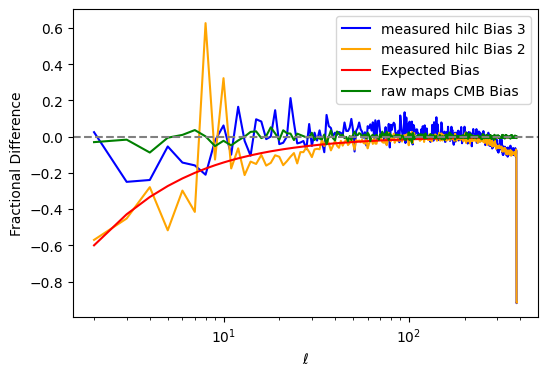

In [13]:
plt.figure(figsize=(6, 4))
plt.plot(ells[2:],hilc3_bias, label="measured hilc Bias 3", color="blue") #no fgds
plt.plot(ells[2:],hilc2_bias, label="measured hilc Bias 2", color="orange") #with fgds
plt.plot(ells[2:], -3/(2*ells[2:]+1), label="Expected Bias", color="red")
plt.plot(ells[2:], raw_bias, label="raw maps CMB Bias", color="green")
# plt.plot(ells[2:], bias, label="raw decoupled", color="magenta")
plt.axhline(0, linestyle="--", color="gray")  # Reference line

#plt.ylim(-0.06, 0.06)

plt.xscale("log")

plt.xlabel(r"$\ell$")
plt.ylabel(r"Fractional Difference")

plt.legend()
plt.show()

NameError: name 'hilc_mean' is not defined

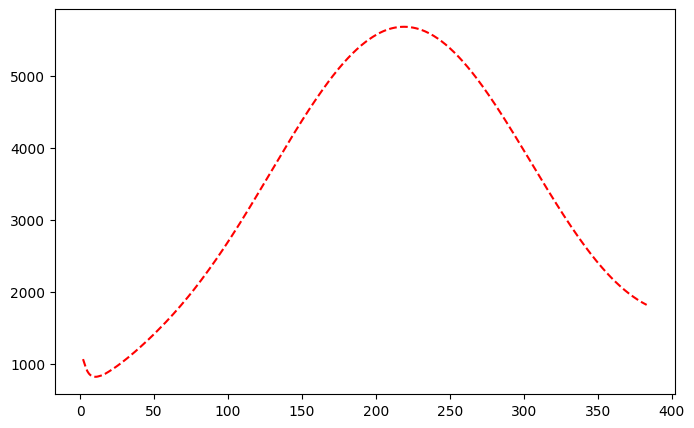

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

# Plot the input and recovered power spectra
ax.plot(ells[2:], cmb_th, 'r--', label='Theoretical CMB')

ax.errorbar(ells[2:], norm[2:]*hilc_mean[2:,0,0], yerr=hilc_error,ecolor='g', fmt='k.', label='masked HILC')
ax.errorbar(ells[2:], hilc2_mean[2:,0,0], yerr=hilc2_error,ecolor='g', fmt='b.', label='masked HILC 2')


ax.errorbar(ells[2:], norm[2:]*cmb_mean[2:,0,0], yerr=cmb_error,ecolor='m', fmt='g.-', label='masked + decoupled CMB')
ax.errorbar(ells[2:],raw_mean, yerr=raw_error,ecolor='c', fmt='y.', label='raw maps')

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel(r'$\ell$', fontsize=16)
ax.set_ylabel(r'$C_\ell$', fontsize=16)
ax.legend()
# ax.set_ylim([1e2, 1e4])


# Bias plot
fig, ax2 = plt.subplots(figsize=(8, 3))
ax2.errorbar(ells[2:], raw_bias, yerr=raw_error, ecolor='m',fmt='bx--', label='raw maps Bias')
ax2.axhline(0, color='k', linestyle='--')
ax2.errorbar(ells[2:], hilc2_bias, yerr=hilc2_error, ecolor='g',fmt='k.--', label='HILC Bias')
ax2.set_xlabel(r'$\ell$', fontsize=16)
ax2.set_ylabel(r'Bias: $C_\ell^{\text{out}} - C_\ell^{\text{in}}$', fontsize=16)
ax2.set_xscale('log')
ax2.set_ylim(-0.5,0.5)
ax2.legend()
plt.show()